<a href="https://colab.research.google.com/github/Ashfakur-Rahman/AI-ML-Batch-2-AI-Programming-With-Python/blob/main/ML_EDA_Module1_Practice_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis - Penguin Dataset (Practice Solutions)

This notebook walks through the EDA tasks for the Palmer Penguins dataset using pandas, matplotlib, and seaborn.  
All code is executed in a Colab environment.

---

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = sns.load_dataset('penguins')

#Task 1: Basic Exploration
##Questions:

* Total number of samples (rows) and features (columns)?

* Display first 7 rows.

* Display random sample of 5 rows.

* Why is a random sample sometimes better than just the top rows?

In [2]:
# 1. Shape
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 2. First 7 rows
print("\nFirst 7 rows:")
display(df.head(7))

# 3. Random 5 rows
print("\nRandom 5 rows:")
display(df.sample(5, random_state=42))  # setting seed for reproducibility

Rows: 344, Columns: 7

First 7 rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female



Random 5 rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
194,Chinstrap,Dream,50.9,19.1,196.0,3550.0,Male
157,Chinstrap,Dream,45.2,17.8,198.0,3950.0,Female
225,Gentoo,Biscoe,46.5,13.5,210.0,4550.0,Female
208,Chinstrap,Dream,45.2,16.6,191.0,3250.0,Female
318,Gentoo,Biscoe,48.4,14.4,203.0,4625.0,Female


##Answer to "Why random sample?"

Looking at a random sample avoids any bias that may be introduced by the order of the data (e.g., sorted by species or island). It gives a more representative glimpse of the overall dataset.

#Task 2: Missing Values
##Questions:

* Calculate total missing values per column.

* Which feature has the highest number of missing values?

In [3]:
# Missing values per column
missing = df.isnull().sum()
print("Missing values per column:\n", missing)

# Feature with most missing
most_missing = missing.idxmax()
max_count = missing.max()
print(f"\nFeature with highest missing values: '{most_missing}' ({max_count} missing)")

Missing values per column:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Feature with highest missing values: 'sex' (11 missing)


#Task 3: Duplicate Rows
##Questions:

* Check if there are any duplicate rows; how many?

* Permanently remove duplicates.

In [4]:
# Count duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Remove duplicates (permanently)
df.drop_duplicates(inplace=True)
print("Duplicates removed. New shape:", df.shape)

Number of duplicate rows: 0
Duplicates removed. New shape: (344, 7)


#Task 4: Summary and Statistics
##Questions:

* Print a concise summary (data types, non-null counts).

* Generate statistical summary for numerical columns.

* What is the maximum body_mass_g and average flipper_length_mm?

In [5]:
# Concise summary
print("DataFrame info:")
df.info()

# Statistical summary for numerical columns
print("\nStatistical summary (numerical):")
display(df.describe())

# Extract specific values
max_mass = df['body_mass_g'].max()
mean_flipper = df['flipper_length_mm'].mean()
print(f"\nMaximum body_mass_g: {max_mass} g")
print(f"Average flipper_length_mm: {mean_flipper:.2f} mm")

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB

Statistical summary (numerical):


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000



Maximum body_mass_g: 6300.0 g
Average flipper_length_mm: 200.92 mm


#Task 5: Species Distribution (Count Plot)
##Questions:

* Create a Seaborn count plot for species.

* Which species is the most common?

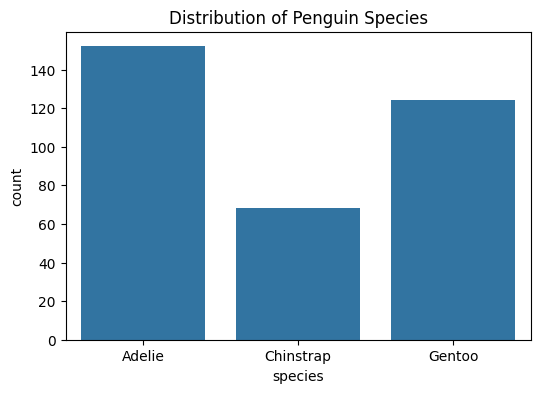

Most common species: Adelie (152 individuals)


In [6]:
# Count plot
plt.figure(figsize=(6,4))
sns.countplot(x='species', data=df)
plt.title('Distribution of Penguin Species')
plt.show()

# Most common species
species_counts = df['species'].value_counts()
most_common = species_counts.idxmax()
print(f"Most common species: {most_common} ({species_counts.max()} individuals)")

#Task 6: Percentage Distribution of Island

In [7]:
# Percentage distribution
island_percent = df['island'].value_counts(normalize=True) * 100
print("Island percentage distribution:\n", island_percent.round(2))

Island percentage distribution:
 island
Biscoe       48.84
Dream        36.05
Torgersen    15.12
Name: proportion, dtype: float64


#Task 7: Gender Distribution (Pie Chart)
##Questions:

* Extract value counts for sex.

* Create a pie chart with male/female distribution.

* Include percentage labels with one decimal and a title.

Sex counts:
 sex
Male      168
Female    165
Name: count, dtype: int64


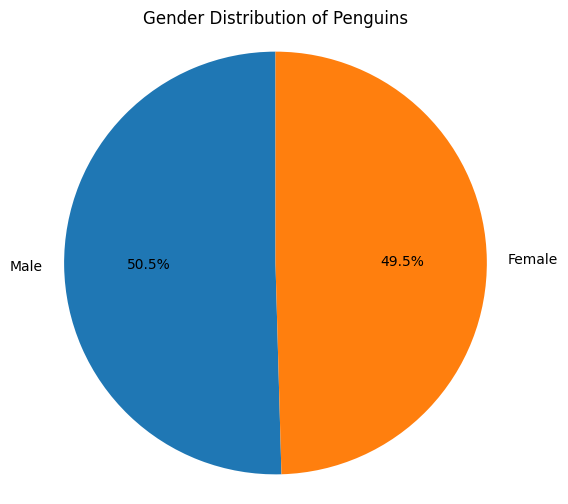

In [8]:
# Value counts for sex (dropping NA automatically)
sex_counts = df['sex'].value_counts()
print("Sex counts:\n", sex_counts)

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(sex_counts, labels=sex_counts.index, autopct='%.1f%%', startangle=90)
plt.title('Gender Distribution of Penguins')
plt.axis('equal')  # Equal aspect ratio ensures the pie is circular.
plt.show()

#Final Notes
* The dataset after removing duplicates may have slightly different counts, but all operations are applied in place.

* Missing values are not imputed here, but they are identified for potential further handling.

* All visualizations are created with standard matplotlib/seaborn settings.